# Advanced Machine Learning: Concrete Compressive Strength Prediction

## Authors 

- Arthur DANJOU
- Axelle MERIC
- Moritz VON SIEMENS

## Packages import

In [63]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb

import sys
import types

mock_pkg_resources = types.ModuleType("pkg_resources")
mock_pkg_resources.get_distribution = lambda x: type(
    "obj", (object,), {"version": "0.0.0"}
)
mock_pkg_resources.DistributionNotFound = Exception

sys.modules["pkg_resources"] = mock_pkg_resources

from ace.model import Model
from boruta import BorutaPy
from PyALE import ale

from IPython.display import display
from sklearn.ensemble import IsolationForest, RandomForestRegressor, StackingRegressor
from sklearn.feature_selection import RFECV
from sklearn.inspection import PartialDependenceDisplay
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import Lasso, LassoCV, Ridge, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, mutual_info_score, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
from sklearn.svm import SVR

# Aesthetic parameters
sns.set_theme(style="whitegrid")
colors = sns.color_palette("magma", 6)

# Export settings for clean report generation
REPORT_EXPORT_MODE = True
REPORT_FIG_DIR = Path("figures")

def finalize_figure(*, title=None, tight_layout=True, filename=None, show=None):
    if title is not None:
        plt.title(title)
    if tight_layout:
        plt.tight_layout()
    if filename is not None and REPORT_EXPORT_MODE:
        REPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)
        plt.savefig(REPORT_FIG_DIR / filename, bbox_inches="tight", dpi=300)
    if show is None:
        show = not REPORT_EXPORT_MODE
    if show:
        plt.show()
    else:
        plt.close()

# Silence known non-blocking warnings from third-party internals
warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    message="invalid value encountered in scalar divide",
)
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message=r"The NumPy global RNG was seeded by calling `np\.random\.seed`.*",
)


# 1. Introduction 

## 1.1. Dataset presentation

### Dataset import

In [64]:
data = pd.read_csv('./data/Concrete_Data.csv', sep=';', decimal=',')
print(f"Dataset shape: {data.shape}")


Dataset shape: (1030, 9)


### Dataset exploration

In [65]:
data.columns


Index(['Cement (component 1)(kg in a m^3 mixture)',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
       'Fly Ash (component 3)(kg in a m^3 mixture)',
       'Water  (component 4)(kg in a m^3 mixture)',
       'Superplasticizer (component 5)(kg in a m^3 mixture)',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)',
       'Concrete compressive strength(MPa, megapascals) '],
      dtype='str')

In [66]:
# Renaming columns for easier manipulation
data.columns = [
    'Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 
    'Superplasticizer', 'Coarse_Aggregate', 'Fine_Aggregate', 
    'Age', 'Compressive_Strength'
]


In [67]:
data.head()


,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Compressive_Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [68]:
data.tail()


,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Compressive_Strength
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77
1029,260.9,100.5,78.3,200.6,8.6,864.5,761.5,28,32.40


In [69]:
data.describe(include="all")


,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Compressive_Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [70]:
data.dtypes


Cement                  float64
Blast_Furnace_Slag      float64
Fly_Ash                 float64
Water                   float64
Superplasticizer        float64
Coarse_Aggregate        float64
Fine_Aggregate          float64
Age                       int64
Compressive_Strength    float64
dtype: object

In [71]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Cement                1030 non-null   float64
 1   Blast_Furnace_Slag    1030 non-null   float64
 2   Fly_Ash               1030 non-null   float64
 3   Water                 1030 non-null   float64
 4   Superplasticizer      1030 non-null   float64
 5   Coarse_Aggregate      1030 non-null   float64
 6   Fine_Aggregate        1030 non-null   float64
 7   Age                   1030 non-null   int64  
 8   Compressive_Strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [72]:
TARGET_VARIABLE = "Compressive_Strength"
RANDOM_SEED = 2711


## 1.2. Train/Test Split

In [73]:
X = data.drop(columns=[TARGET_VARIABLE])
y = data[TARGET_VARIABLE]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=RANDOM_SEED
)

train_data = pd.concat([X_train, y_train], axis=1)

print(f"Size of the training set: {train_data.shape}")
print(f"Size of the testing set: {X_test.shape[0]} lines")


Size of the training set: (824, 9)
Size of the testing set: 206 lines


## 1.3. Exploratory Data Analysis (EDA)

### 1.3.1. Target variable

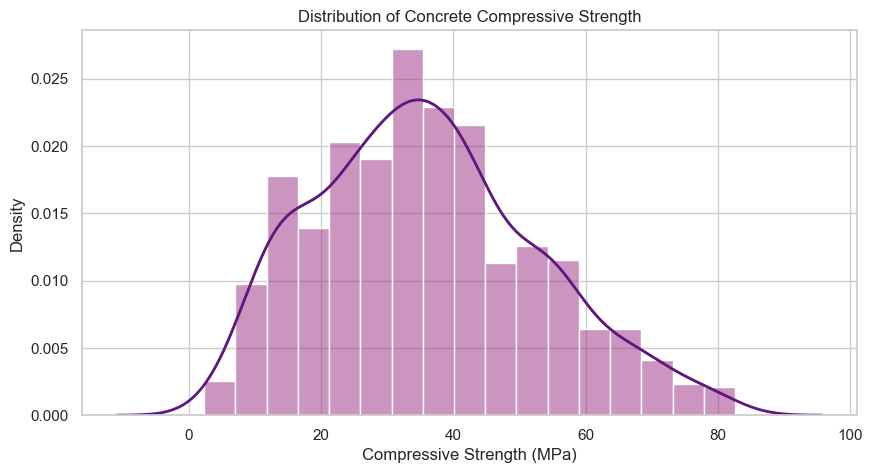

In [74]:
plt.figure(figsize=(10, 5))
sns.histplot(
    train_data[TARGET_VARIABLE],
    kde=True,
    color=colors[2],
    edgecolor="white",
    stat="density",
)
sns.kdeplot(train_data[TARGET_VARIABLE], color=colors[1], linewidth=2)

plt.title("Distribution of Concrete Compressive Strength")
plt.xlabel("Compressive Strength (MPa)")
plt.ylabel("Density")
plt.show()


In [75]:
train_data[TARGET_VARIABLE].describe()


count    824.000000
mean      35.971529
std       16.754832
min        2.330000
25%       23.972500
50%       34.565000
75%       46.285000
max       82.600000
Name: Compressive_Strength, dtype: float64

### 1.3.2. EDA of the eight other features 

#### Distributions

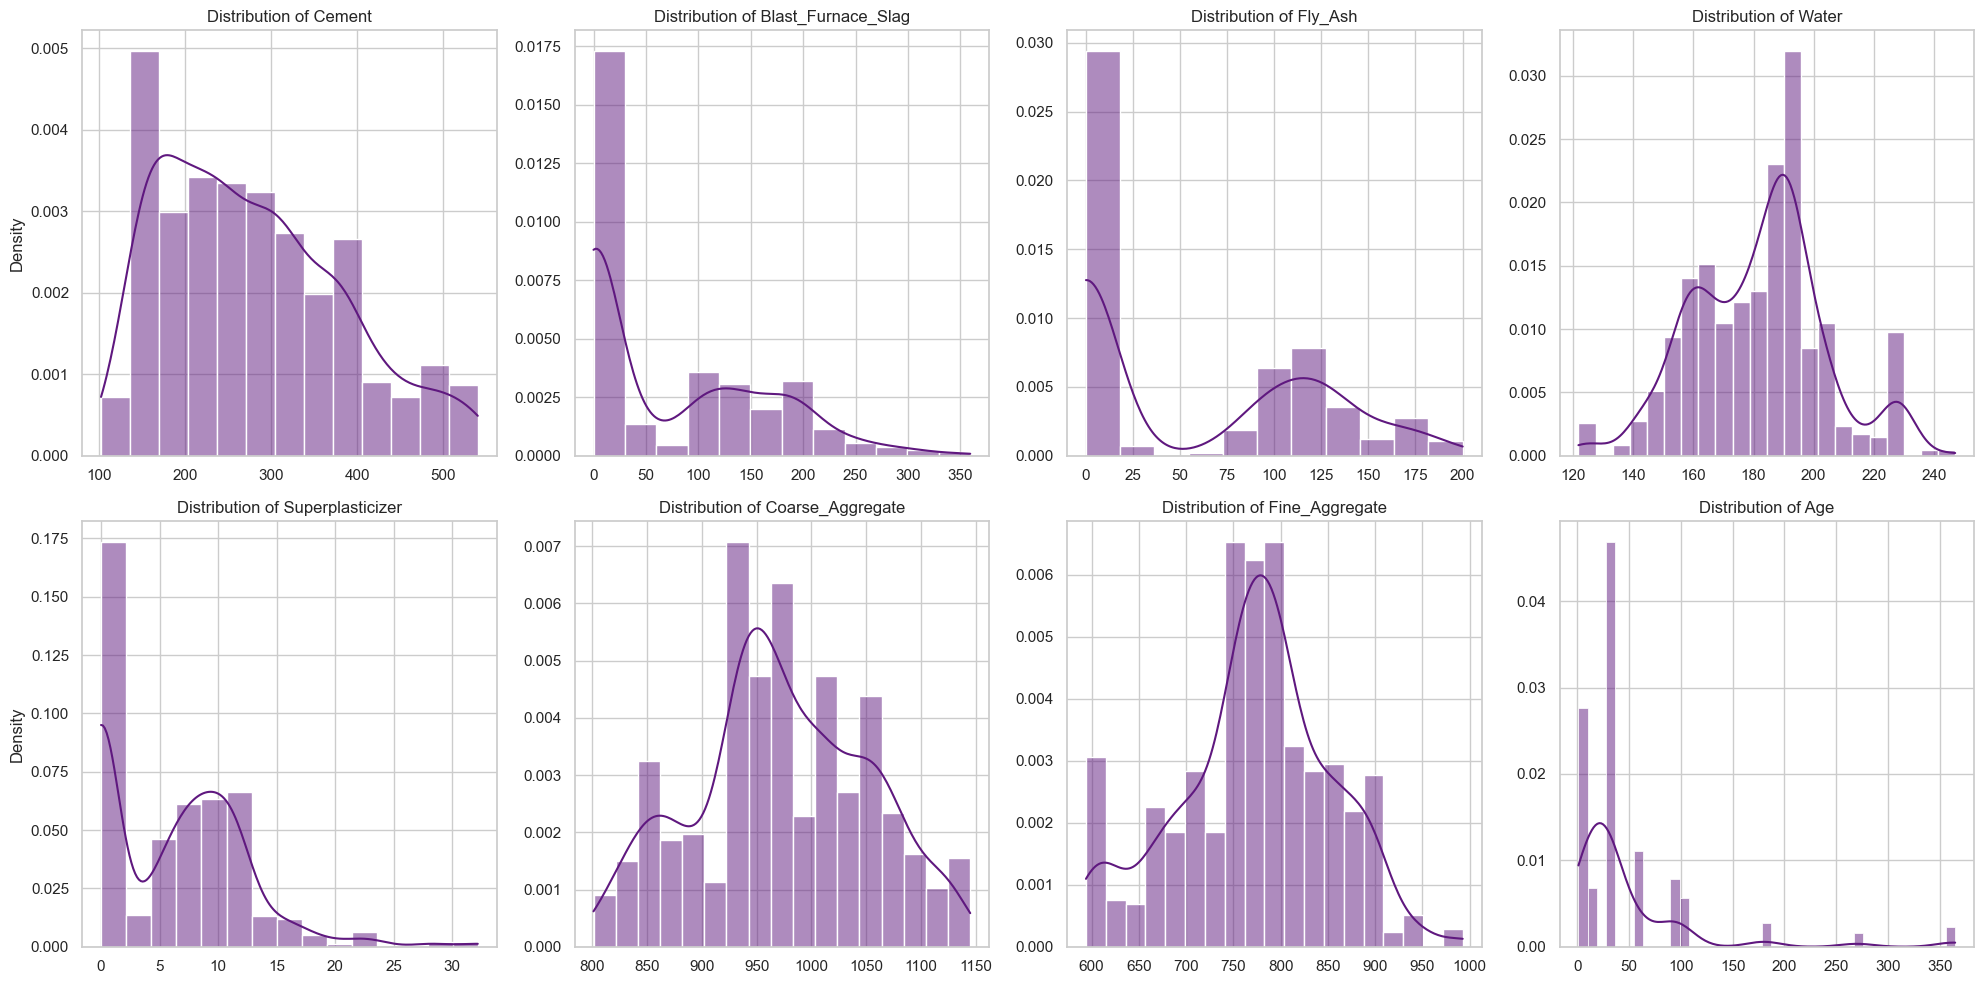

In [76]:
features = [col for col in train_data.columns if col != TARGET_VARIABLE]

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(
        train_data[col], 
        kde=True, 
        color=colors[1], 
        edgecolor="white", 
        stat="density",
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {col}", fontsize=12)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Density" if i % 4 == 0 else "")

plt.tight_layout()
plt.show()


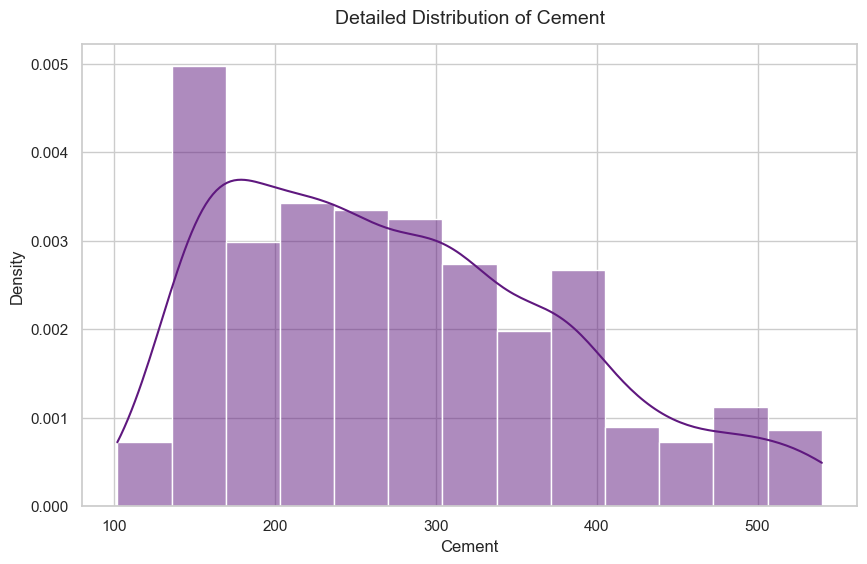

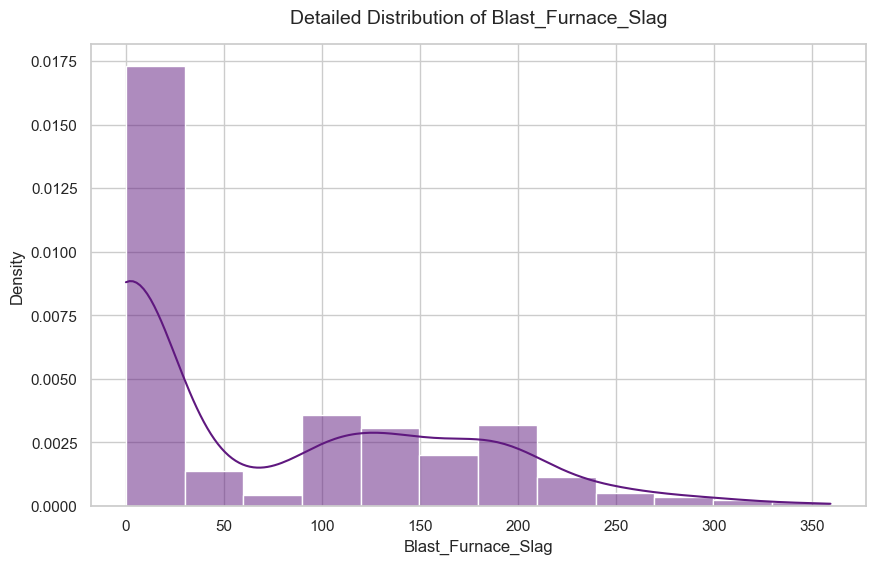

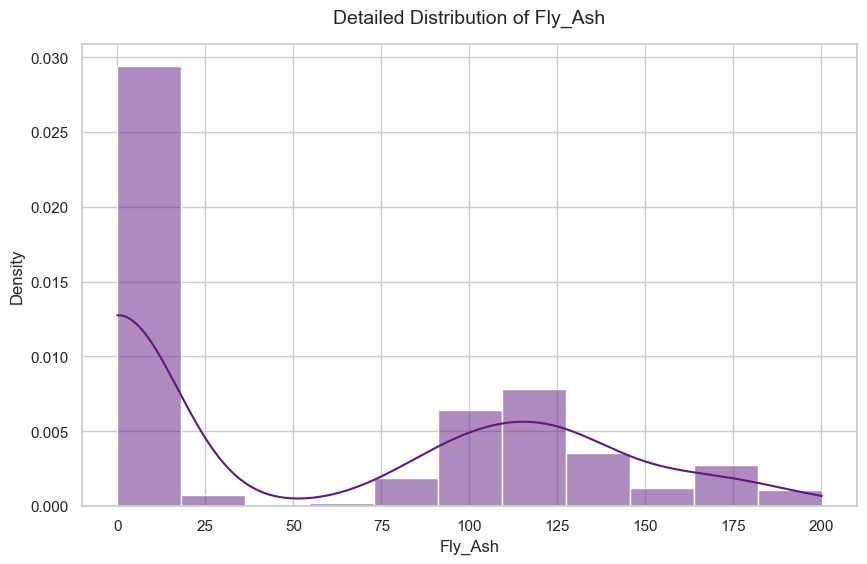

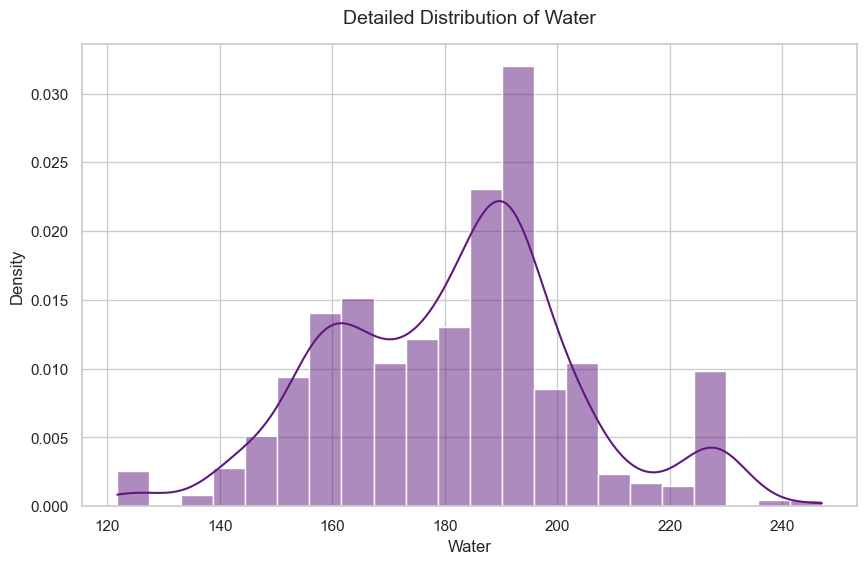

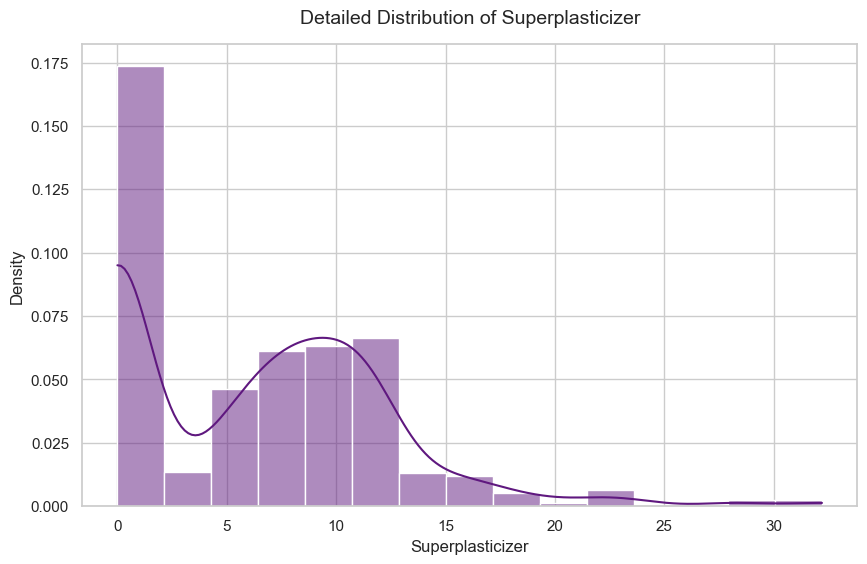

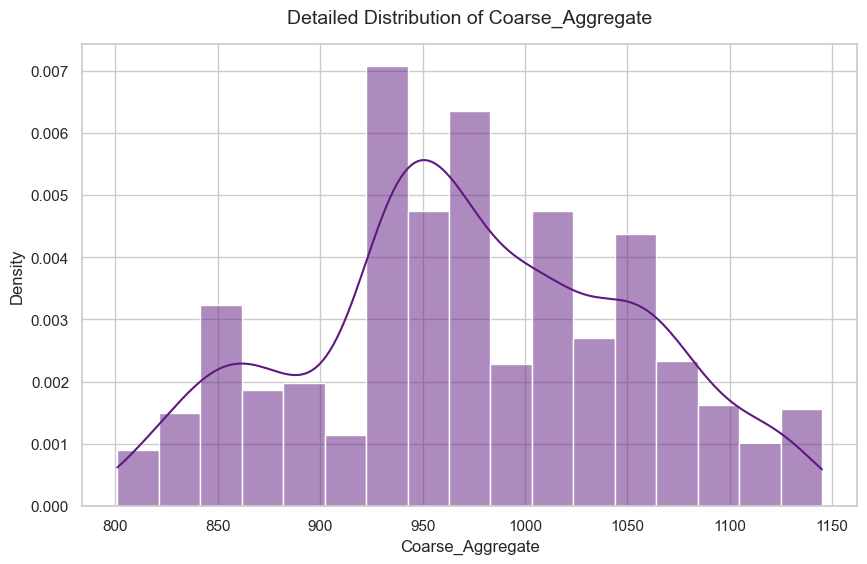

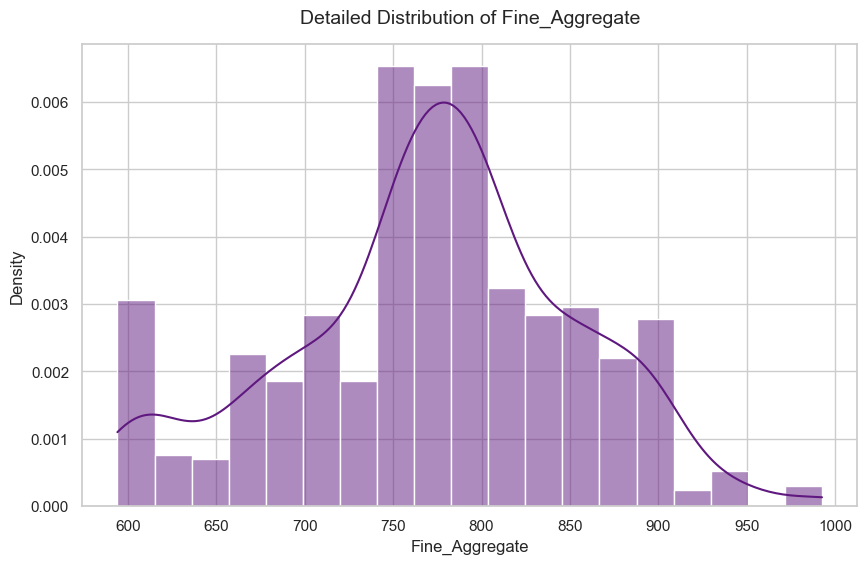

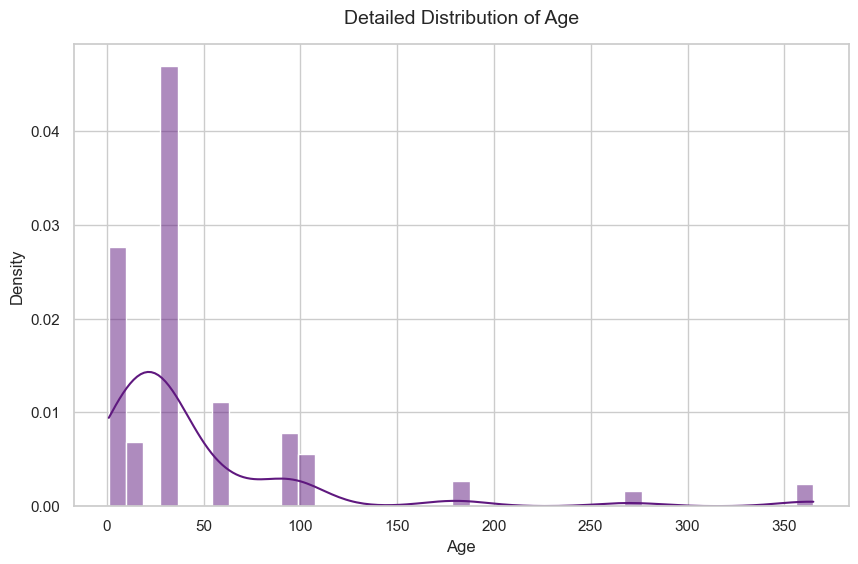

In [77]:
for col in features:
    plt.figure(figsize=(10, 6))
    sns.histplot(
        train_data[col], 
        kde=True, 
        color=colors[1], 
        edgecolor="white", 
        stat="density"
    )
    plt.title(f"Detailed Distribution of {col}", fontsize=14, pad=15)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.show()


#### Features vs Target (Regplots)

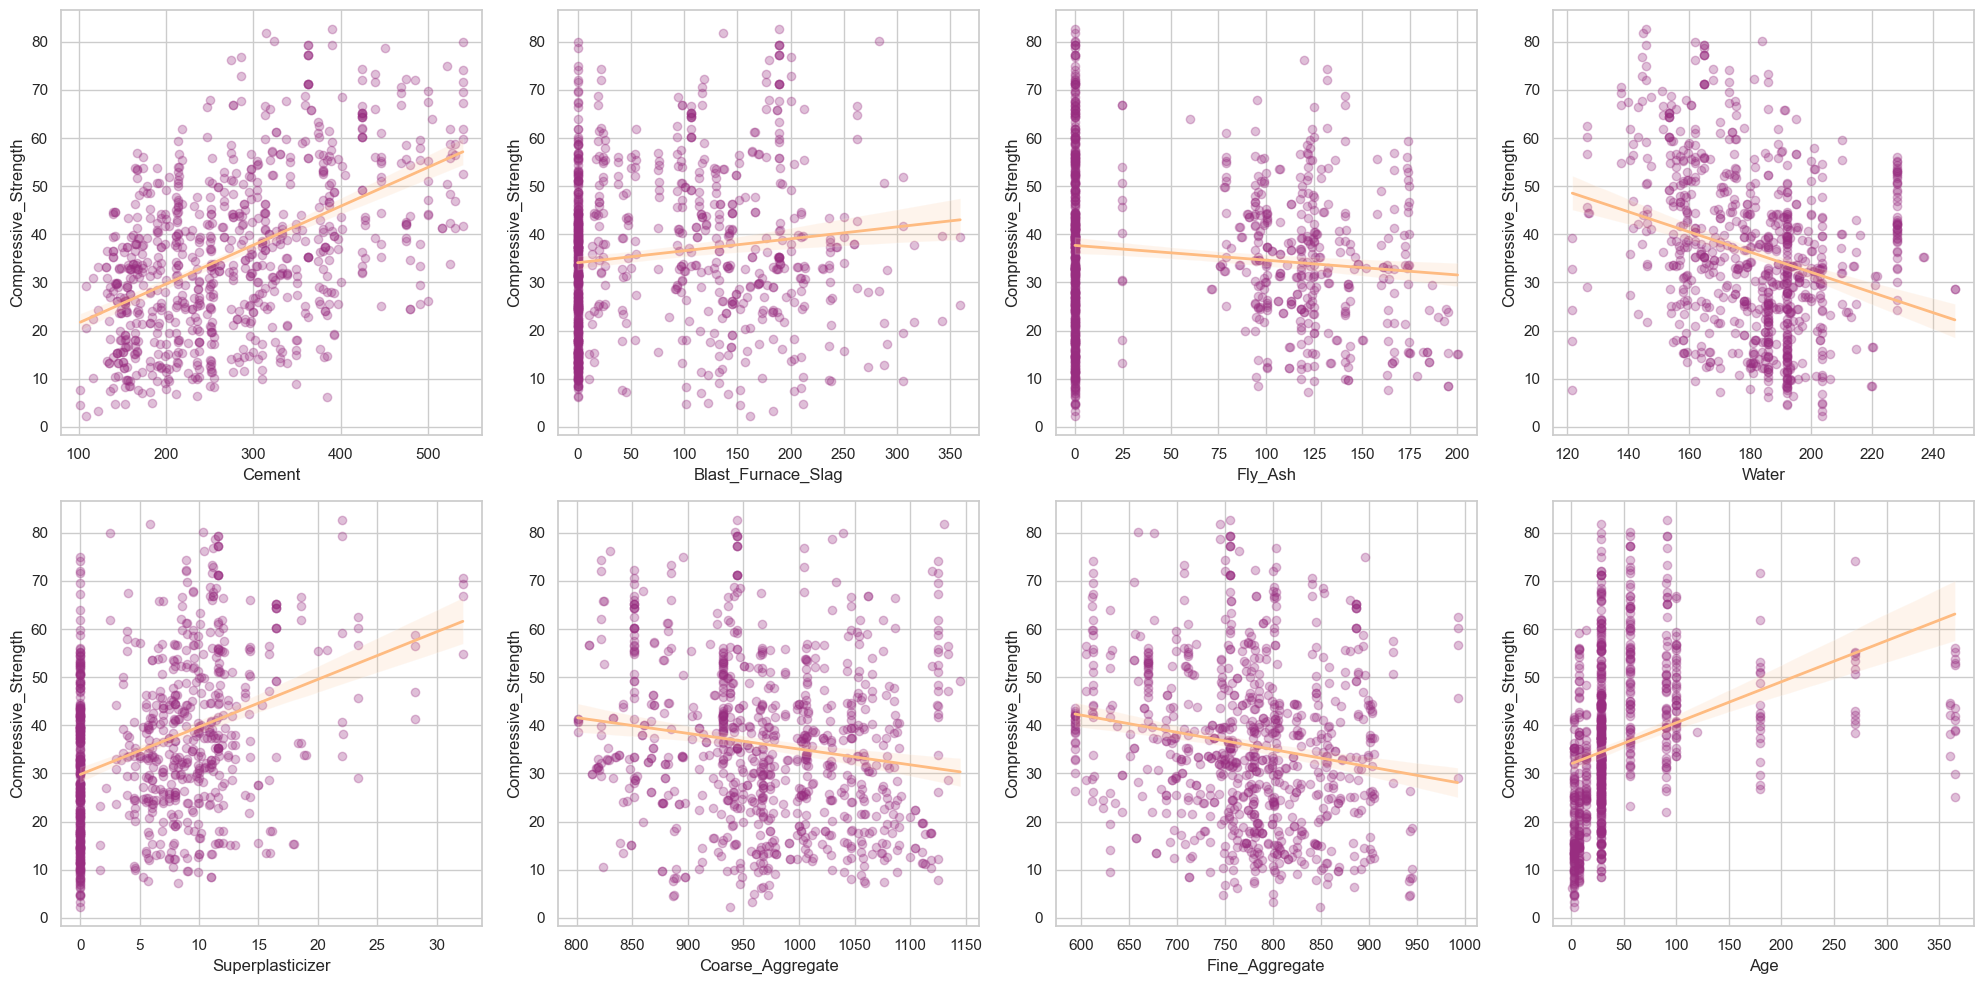

In [78]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.regplot(
        x=col, 
        y=TARGET_VARIABLE, 
        data=train_data, 
        ax=axes[i],
        scatter_kws={"alpha": 0.3, "color": colors[2]}, 
        line_kws={"color": colors[5], "lw": 2}
    )

plt.tight_layout()
plt.show()


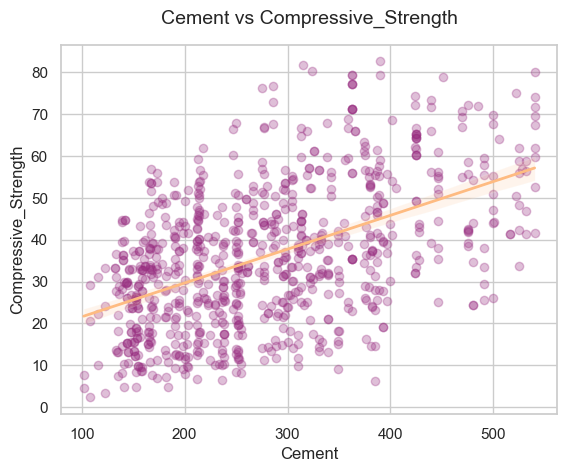

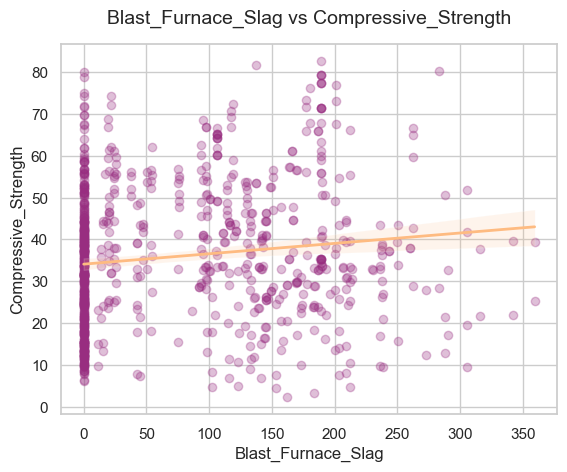

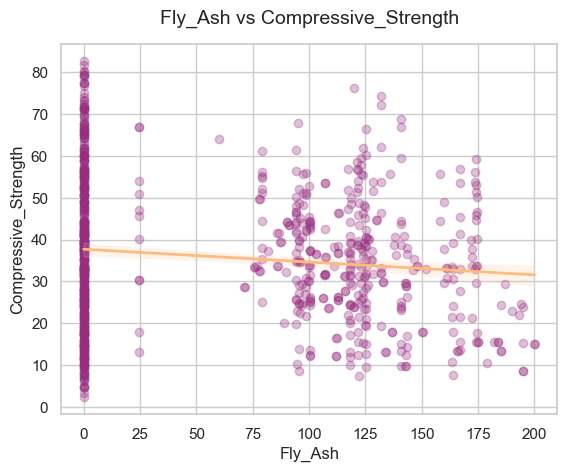

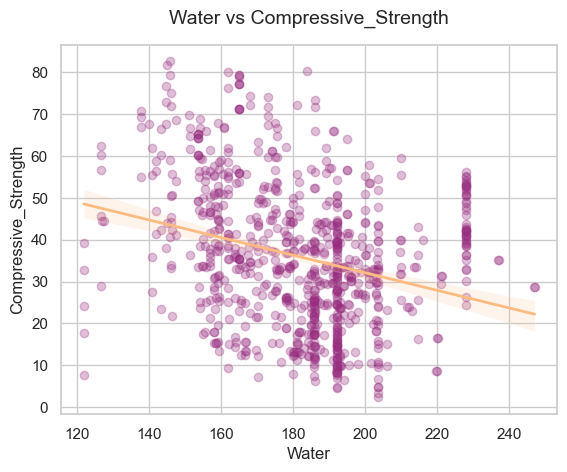

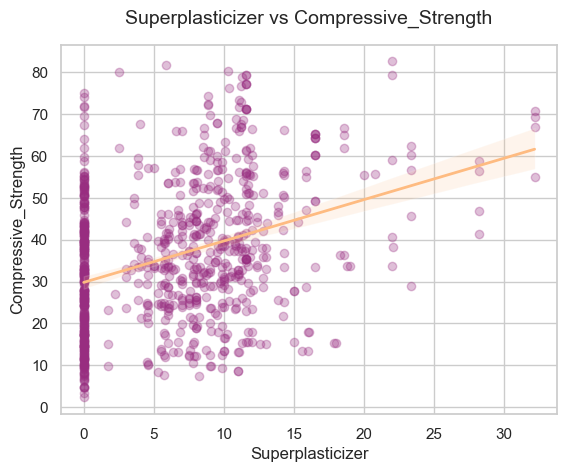

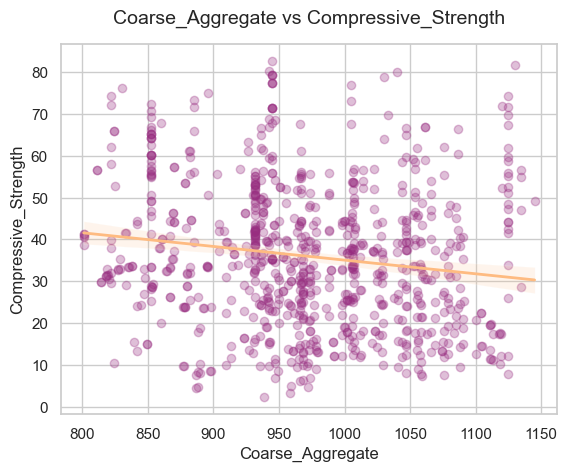

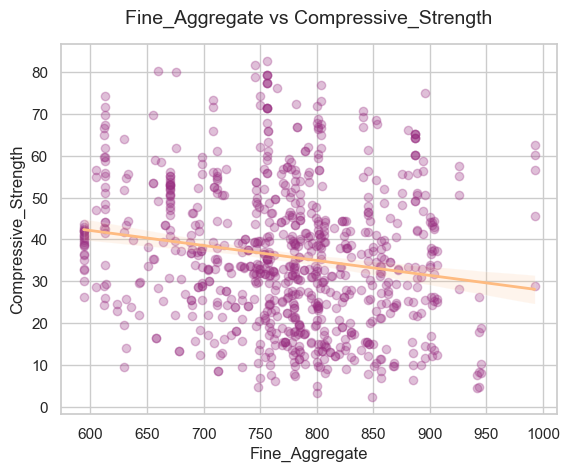

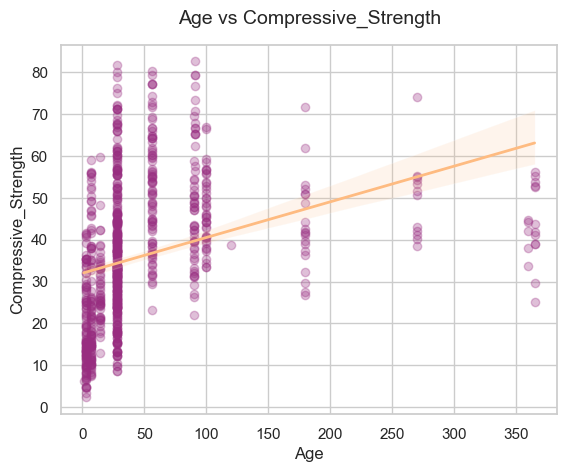

In [79]:
for col in features:
    sns.regplot(
        x=col, 
        y=TARGET_VARIABLE, 
        data=train_data, 
        scatter_kws={"alpha": 0.3, "color": colors[2]}, 
        line_kws={"color": colors[5], "lw": 2}
    )

    plt.title(f"{col} vs {TARGET_VARIABLE}", fontsize=14, pad=15)
    plt.xlabel(col, fontsize=12)
    plt.ylabel(TARGET_VARIABLE, fontsize=12)
    plt.show()


#### Global Boxplot for Scale Comparison

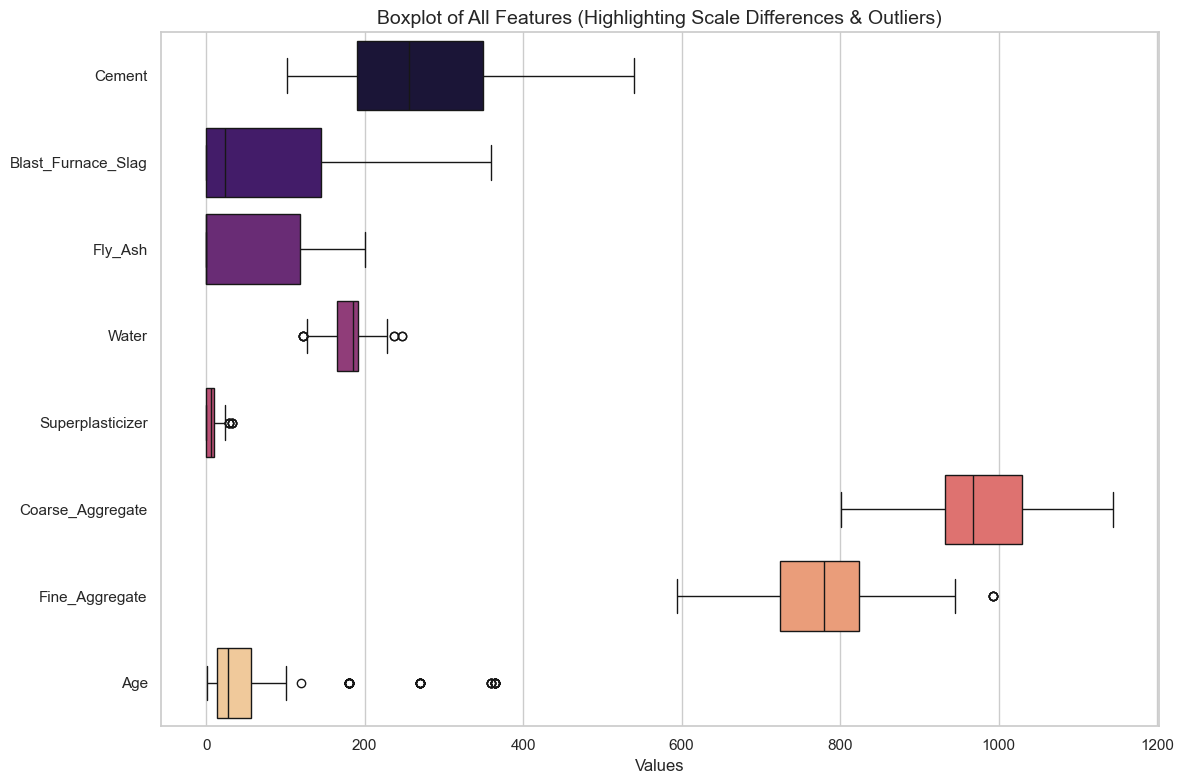

In [80]:
plt.figure(figsize=(12, 8))
sns.boxplot(
    data=train_data[features], 
    orient="h", 
    palette="magma"
)
plt.title("Boxplot of All Features (Highlighting Scale Differences & Outliers)", fontsize=14)
plt.xlabel("Values")
plt.tight_layout()
plt.show()


# 2. Pre-processing

## 2.1. Outlier Detection with Isolation Forest

In [81]:
# Initialisation
iso_forest = IsolationForest(contamination=0.05, random_state=RANDOM_SEED)

# Fit and predict (-1 for outliers, 1 for inliers) on X_train
train_data['Outlier'] = iso_forest.fit_predict(X_train)

# Count outliers
num_outliers = (train_data['Outlier'] == -1).sum()
print(f"Number of outliers detected: {num_outliers}")

# Filter the dataset to keep only normal data points AND drop the 'Outlier' column
train_data_clean = train_data[train_data['Outlier'] == 1].drop(columns=['Outlier']).reset_index(drop=True)

print(f"Cleaned training dataset shape: {train_data_clean.shape}")


Number of outliers detected: 42
Cleaned training dataset shape: (782, 9)


## 2.2. Features scaling

In [82]:
X_train_clean = train_data_clean.drop(columns=[TARGET_VARIABLE])
y_train_clean = train_data_clean[TARGET_VARIABLE]

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform on the clean TRAINING set
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_clean), 
    columns=features, 
    index=X_train_clean.index
)

# Transform the TESTING set using the parameters learned from the training set
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), 
    columns=features, 
    index=X_test.index
)

print("Scaled Training Data Verification:")
display(X_train_scaled.describe().round(2).loc[['mean', 'std']])


Scaled Training Data Verification:


,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age
mean,0.0,-0.0,0.0,-0.0,0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


# 3. Variable selection & engineering

## 3.1. Pre-selection: Linear Correlation Analysis

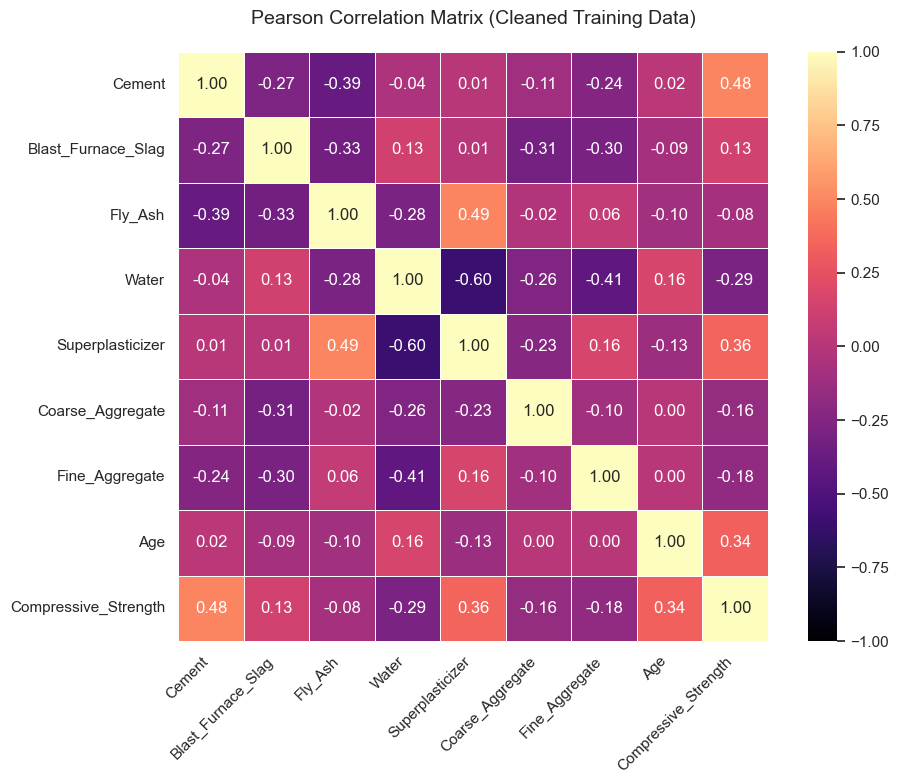

--- Correlation with Target ---
Cement                0.484803
Superplasticizer      0.357058
Age                   0.335620
Blast_Furnace_Slag    0.132831
Fly_Ash              -0.083935
Coarse_Aggregate     -0.161420
Fine_Aggregate       -0.175883
Water                -0.285399
Name: Compressive_Strength, dtype: float64


In [83]:
plt.figure(figsize=(10, 8))
correlation_matrix = train_data_clean.corr(method='pearson')
#mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(
    correlation_matrix, 
    #mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap=sns.color_palette("magma", as_cmap=True), 
    vmin=-1, vmax=1, 
    square=True, 
    linewidths=0.5
)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.title("Pearson Correlation Matrix (Cleaned Training Data)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()


target_corr = correlation_matrix[TARGET_VARIABLE].drop(TARGET_VARIABLE).sort_values(ascending=False)
print("--- Correlation with Target ---")
print(target_corr)


## 3.2. Domain-Specific Feature Engineering

In [84]:
X_train_eng = X_train_clean.copy()
X_test_eng = X_test.copy()


### Ratio 1: Water to Cement

In [85]:
X_train_eng['Water_Cement_Ratio'] = X_train_eng['Water'] / (X_train_eng['Cement'] + 1e-5)
X_test_eng['Water_Cement_Ratio'] = X_test_eng['Water'] / (X_test_eng['Cement']+ 1e-5)


### Ratio 2: Water to Binder (Binder = Cement + Slag + Ash)

In [86]:
X_train_eng['Water_Binder_Ratio'] = X_train_eng['Water'] / (X_train_eng['Cement'] + X_train_eng['Blast_Furnace_Slag'] + X_train_eng['Fly_Ash'] + 1e-5)
X_test_eng['Water_Binder_Ratio'] = X_test_eng['Water'] / (X_test_eng['Cement'] + X_test_eng['Blast_Furnace_Slag'] + X_test_eng['Fly_Ash'] + 1e-5)


### Ratio 3: Coarse to Fine Aggregate Ratio

In [87]:
X_train_eng['Aggregate_Ratio'] = X_train_eng['Coarse_Aggregate'] / (X_train_eng['Fine_Aggregate'] + 1e-5)
X_test_eng['Aggregate_Ratio'] = X_test_eng['Coarse_Aggregate'] / (X_test_eng['Fine_Aggregate'] + 1e-5)


### Resclaing 

In [88]:
features_eng = X_train_eng.columns.tolist()
scaler_eng = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler_eng.fit_transform(X_train_eng), 
    columns=features_eng, 
    index=X_train_eng.index
)
X_test_scaled = pd.DataFrame(
    scaler_eng.transform(X_test_eng), 
    columns=features_eng, 
    index=X_test_eng.index
)
print(f"New number of features: {len(features_eng)}")
display(X_train_scaled.describe().round(2).loc[['mean', 'std']])


New number of features: 11


,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Water_Cement_Ratio,Water_Binder_Ratio,Aggregate_Ratio
mean,0.0,-0.0,0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [89]:
plt.figure(figsize=(12, 8))
sns.boxplot(
    data=X_train_scaled,
    orient="h",
    palette="magma",
)
plt.xlabel("Scaled Values (Z-score)")

finalize_figure(
    title="Boxplot of All Features (After Engineering & Scaling)",
    filename="features_boxplots_scaled.png",
)


## 3.3. Filter Method: CMIM

/Users/arthurdanjou/Workspace/Advanced-Machine-Learning-Concrete-Compressive-Strength-Prediction/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/Users/arthurdanjou/Workspace/Advanced-Machine-Learning-Concrete-Compressive-Strength-Prediction/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/Users/arthurdanjou/Workspace/Advanced-Machine-Learning-Concrete-Compressive-Strength-Prediction/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_discretization.py:39

CMIM Scores:
Age                   0.5767
Water_Binder_Ratio    0.3096
Water_Cement_Ratio    0.2909
Water                 0.2753
Aggregate_Ratio       0.2752
Coarse_Aggregate      0.2523
Fine_Aggregate        0.2494
Superplasticizer      0.2261
Blast_Furnace_Slag    0.1716
Cement                0.1666
Fly_Ash               0.1165
dtype: float64


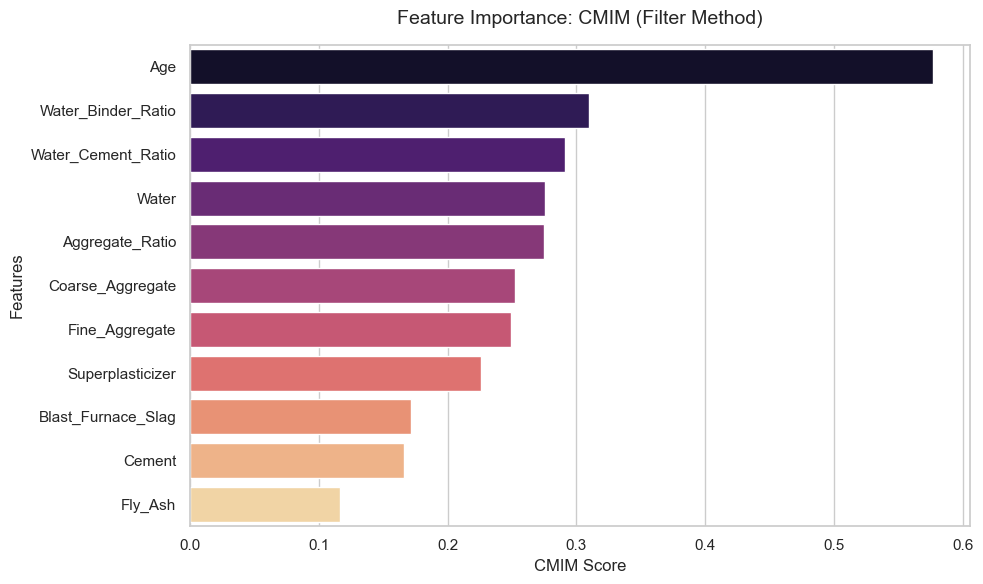

In [90]:
discretizer_X = KBinsDiscretizer(n_bins=8, encode="ordinal", strategy="quantile")
X_train_disc = pd.DataFrame(
    discretizer_X.fit_transform(X_train_scaled).astype(int),
    columns=X_train_scaled.columns,
    index=X_train_scaled.index,
)

discretizer_y = KBinsDiscretizer(n_bins=8, encode="ordinal", strategy="quantile")
y_train_disc = discretizer_y.fit_transform(y_train_clean.to_numpy().reshape(-1, 1)).ravel().astype(int)

def _joint_labels(a, b):
    return pd.Series(list(zip(a, b))).astype("category").cat.codes.to_numpy()

def _conditional_mi(x, y, z):
    yz = _joint_labels(y, z)
    return mutual_info_score(x, yz) - mutual_info_score(x, z)

remaining_features = list(X_train_disc.columns)
selected_features = []
cmim_scores = {}

while remaining_features:
    best_feature = None
    best_score = -np.inf

    for feature in remaining_features:
        x_feature = X_train_disc[feature].to_numpy()
        relevance = mutual_info_score(x_feature, y_train_disc)

        if not selected_features:
            score = relevance
        else:
            cond_mi_values = [
                _conditional_mi(x_feature, y_train_disc, X_train_disc[selected].to_numpy())
                for selected in selected_features
            ]
            score = min(cond_mi_values)

        if score > best_score:
            best_score = score
            best_feature = feature

    selected_features.append(best_feature)
    remaining_features.remove(best_feature)
    cmim_scores[best_feature] = best_score

cmim_scores_sorted = pd.Series(cmim_scores).sort_values(ascending=False)

print("CMIM Scores:")
print(cmim_scores_sorted.round(4))

plt.figure(figsize=(10, 6))
sns.barplot(
    x=cmim_scores_sorted.values,
    y=cmim_scores_sorted.index,
    hue=cmim_scores_sorted.index,
    palette="magma",
    legend=False,
)
plt.title("Feature Importance: CMIM (Filter Method)", fontsize=14, pad=15)
plt.xlabel("CMIM Score", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()


## 3.4. Embedded Method: Lasso Regularisation

Optimal Alpha found by CV: 0.0274
Lasso Coefficients:
Age                   7.2094
Water_Binder_Ratio   -6.8266
Cement                6.0282
Blast_Furnace_Slag    3.1511
Superplasticizer      2.9823
Coarse_Aggregate      2.1866
Aggregate_Ratio      -1.4538
Water_Cement_Ratio   -0.0728
Fly_Ash               0.0000
Water                -0.0000
Fine_Aggregate        0.0000
dtype: float64


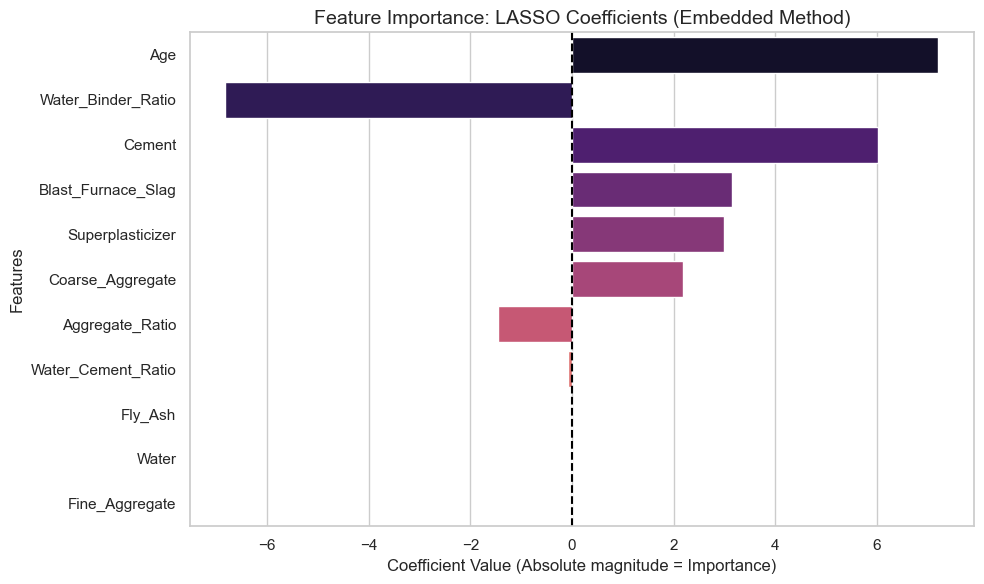

In [91]:
lasso_cv = LassoCV(cv=5, random_state=RANDOM_SEED, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train_clean)

lasso_coefs = pd.Series(lasso_cv.coef_, index=X_train_scaled.columns)
lasso_coefs_sorted = lasso_coefs.sort_values(key=abs, ascending=False)

print(f"Optimal Alpha found by CV: {lasso_cv.alpha_:.4f}")
print("Lasso Coefficients:")
print(lasso_coefs_sorted.round(4))

plt.figure(figsize=(10, 6))
sns.barplot(x=lasso_coefs_sorted.values, 
            y=lasso_coefs_sorted.index, 
            hue = lasso_coefs_sorted.index,
            palette='magma',
            legend = False)
plt.title("Feature Importance: LASSO Coefficients (Embedded Method)", fontsize=14)
plt.xlabel("Coefficient Value (Absolute magnitude = Importance)")
plt.ylabel("Features")
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()


## 3.5. Embedded Method: Random Forest Feature Importance

Random Forest Feature Importances:
Water_Binder_Ratio    0.4099
Age                   0.3546
Water_Cement_Ratio    0.0904
Cement                0.0356
Fly_Ash               0.0244
Blast_Furnace_Slag    0.0166
Aggregate_Ratio       0.0145
Coarse_Aggregate      0.0142
Fine_Aggregate        0.0139
Superplasticizer      0.0130
Water                 0.0129
dtype: float64


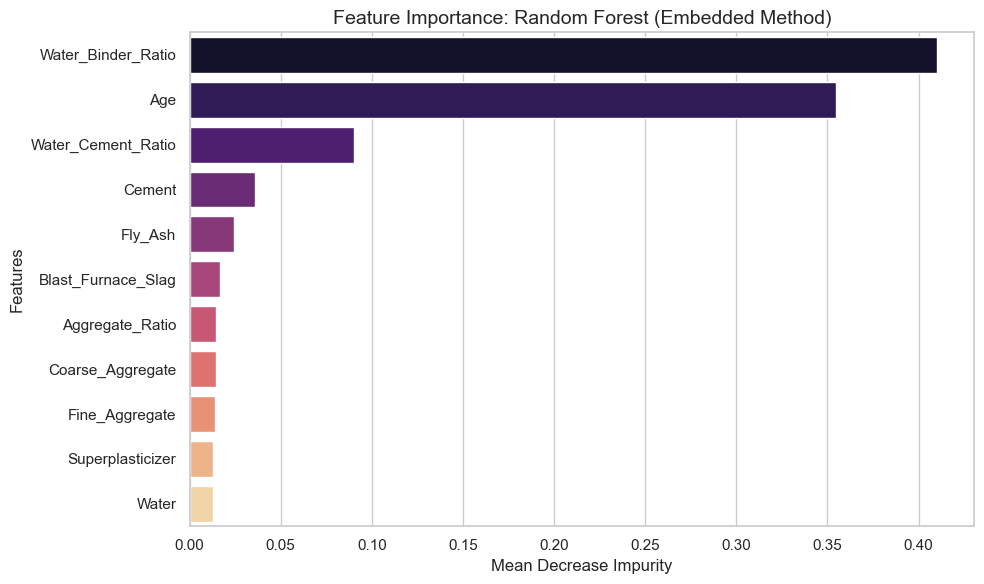

In [92]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED)
rf_model.fit(X_train_scaled, y_train_clean)

rf_importances = pd.Series(rf_model.feature_importances_, index=X_train_scaled.columns)
rf_importances_sorted = rf_importances.sort_values(ascending=False)

print("Random Forest Feature Importances:")
print(rf_importances_sorted.round(4))

plt.figure(figsize=(10, 6))
sns.barplot(x=rf_importances_sorted.values, 
            y=rf_importances_sorted.index, 
            hue = rf_importances_sorted.index, 
            palette="magma",
            legend = False)
plt.title("Feature Importance: Random Forest (Embedded Method)", fontsize=14)
plt.xlabel("Mean Decrease Impurity")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


## 3.6. Wrapper Method: BORUTA

In [93]:
rf_boruta = RandomForestRegressor(n_jobs=-1, max_depth=5, random_state=RANDOM_SEED)

boruta_selector = BorutaPy(
    estimator=rf_boruta, 
    n_estimators='auto', 
    verbose=0, 
    random_state=RANDOM_SEED, 
    max_iter=100
)

boruta_selector.fit(X_train_scaled.values, y_train_clean.values)

boruta_ranking = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Rank': boruta_selector.ranking_,
    'Keep': boruta_selector.support_
}).sort_values(by='Rank')

print("Boruta Selection Results:")
print(boruta_ranking)

confirmed_features = boruta_ranking[boruta_ranking['Keep']]['Feature'].tolist()
print(f"\nBoruta confirmed {len(confirmed_features)} features as important: {confirmed_features}")


Boruta Selection Results:
               Feature  Rank  Keep
0               Cement     1  True
1   Blast_Furnace_Slag     1  True
2              Fly_Ash     1  True
3                Water     1  True
4     Superplasticizer     1  True
5     Coarse_Aggregate     1  True
6       Fine_Aggregate     1  True
7                  Age     1  True
8   Water_Cement_Ratio     1  True
9   Water_Binder_Ratio     1  True
10     Aggregate_Ratio     1  True

Boruta confirmed 11 features as important: ['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 'Superplasticizer', 'Coarse_Aggregate', 'Fine_Aggregate', 'Age', 'Water_Cement_Ratio', 'Water_Binder_Ratio', 'Aggregate_Ratio']


## 3.7. Wrapper Method: Recursive Feature Elimination with Cross-Validation (RFECV)

Optimal number of features: 11

RFECV Selection Results:
               Feature  Rank  Selected
0               Cement     1      True
1   Blast_Furnace_Slag     1      True
2              Fly_Ash     1      True
3                Water     1      True
4     Superplasticizer     1      True
5     Coarse_Aggregate     1      True
6       Fine_Aggregate     1      True
7                  Age     1      True
8   Water_Cement_Ratio     1      True
9   Water_Binder_Ratio     1      True
10     Aggregate_Ratio     1      True


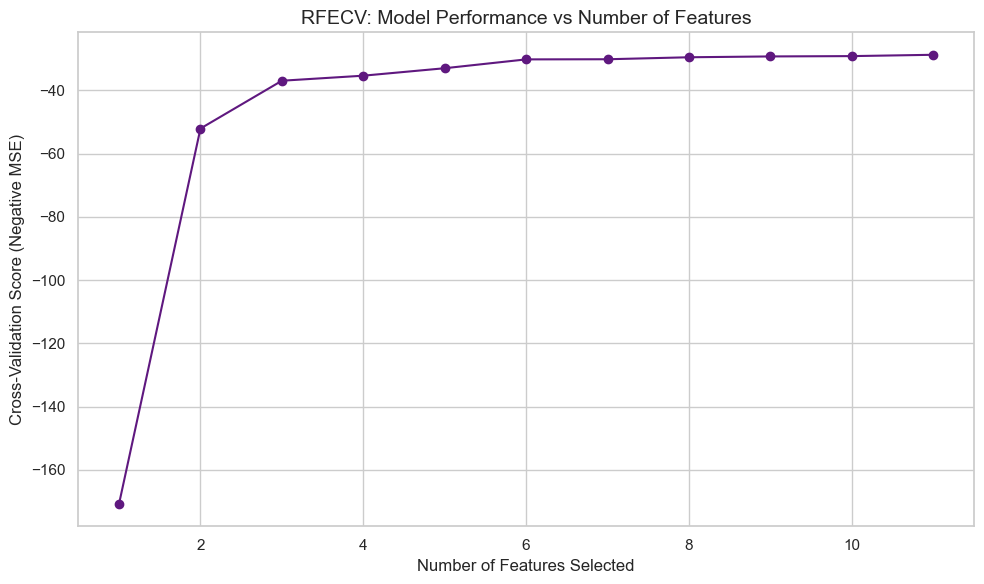

In [94]:
rf_rfecv = RandomForestRegressor(random_state=RANDOM_SEED)

rfecv = RFECV(
    estimator=rf_rfecv, 
    step=1, 
    cv=5, 
    scoring='neg_mean_squared_error', 
    min_features_to_select=1
)

rfecv.fit(X_train_scaled, y_train_clean)

print(f"Optimal number of features: {rfecv.n_features_}")

rfecv_ranking = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Rank': rfecv.ranking_,
    'Selected': rfecv.support_
}).sort_values(by='Rank')

print("\nRFECV Selection Results:")
print(rfecv_ranking)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'], marker='o', color=colors[1])
plt.title("RFECV: Model Performance vs Number of Features", fontsize=14)
plt.xlabel("Number of Features Selected")
plt.ylabel("Cross-Validation Score (Negative MSE)")
plt.grid(True)
plt.tight_layout()
plt.show()


## 3.8. Stability Selection

Stability Selection Scores over 100 iterations:
Cement                1.00
Blast_Furnace_Slag    1.00
Superplasticizer      1.00
Coarse_Aggregate      1.00
Age                   1.00
Water_Binder_Ratio    1.00
Aggregate_Ratio       0.89
Water_Cement_Ratio    0.77
Water                 0.72
Fly_Ash               0.69
Fine_Aggregate        0.52
dtype: float64


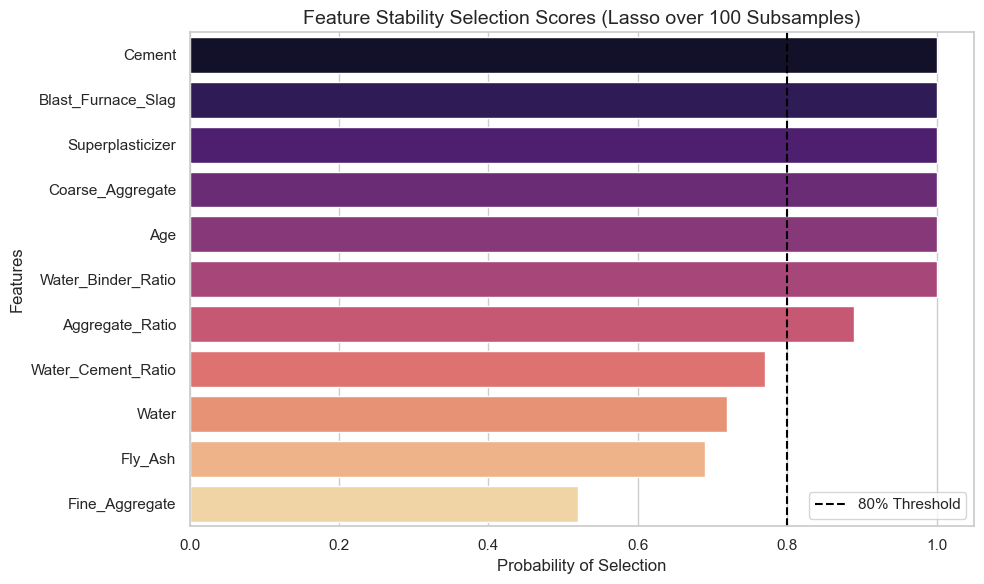

In [95]:
n_iterations = 100
n_samples = X_train_scaled.shape[0]
subsample_size = int(0.75 * n_samples)
selection_counts = np.zeros(X_train_scaled.shape[1])

lasso_stability = Lasso(alpha=0.0274, random_state=None)

rng = np.random.default_rng(RANDOM_SEED)
for i in range(n_iterations):
    indices = rng.choice(n_samples, size=subsample_size, replace=False)
    X_sub = X_train_scaled.iloc[indices]
    y_sub = y_train_clean.iloc[indices]

    lasso_stability.fit(X_sub, y_sub)

    selection_counts += (lasso_stability.coef_ != 0).astype(int)

stability_scores = selection_counts / n_iterations
stability_series = pd.Series(stability_scores, index=X_train_scaled.columns).sort_values(ascending=False)

print("Stability Selection Scores over 100 iterations:")
print(stability_series)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=stability_series.values,
    y=stability_series.index,
    hue=stability_series.index,
    palette="magma",
    legend=False,
 )
plt.title("Feature Stability Selection Scores (Lasso over 100 Subsamples)", fontsize=14)
plt.xlabel("Probability of Selection")
plt.ylabel("Features")
plt.axvline(x=0.8, color="black", linestyle="--", label="80% Threshold")
plt.legend()
plt.tight_layout()
plt.show()


## 3.9. Section Conclusion: The Final Feature Subset

In [96]:
final_features = [
    'Cement', 
    'Blast_Furnace_Slag', 
    'Superplasticizer', 
    'Water_Binder_Ratio', 
    'Coarse_Aggregate', 
    'Age', 
    'Aggregate_Ratio'
]

X_train_reduced = X_train_scaled[final_features]
X_test_reduced = X_test_scaled[final_features]

print(f"Original feature count: {X_train_scaled.shape[1]}")
print(f"Reduced feature count: {X_train_reduced.shape[1]}")
print("\nFinal Features ready for modeling:")
for feat in final_features:
    print(f"- {feat}")


Original feature count: 11
Reduced feature count: 7

Final Features ready for modeling:
- Cement
- Blast_Furnace_Slag
- Superplasticizer
- Water_Binder_Ratio
- Coarse_Aggregate
- Age
- Aggregate_Ratio


# 4. Model Interpretability and Baseline Evaluation

## 4.1. Choice of Metrics

In [97]:
def evaluate_regression_metrics(y_true, y_pred) -> dict:
    """Compute standard regression metrics in a single place."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred),
    }


def print_regression_metrics(title: str, metrics: dict) -> None:
    """Display regression metrics with a consistent format."""
    print(title)
    print(f"MAE:  {metrics['MAE']:.4f}")
    print(f"MSE:  {metrics['MSE']:.4f}")
    print(f"RMSE: {metrics['RMSE']:.4f}")
    print(f"R2:   {metrics['R2']:.4f}")


## 4.2. Baseline Model Performance

In [98]:
rf_baseline = RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED)
rf_baseline.fit(X_train_reduced, y_train_clean)

y_pred_rf = rf_baseline.predict(X_test_reduced)

metrics_rf_reduced = evaluate_regression_metrics(y_test, y_pred_rf)
mae = metrics_rf_reduced["MAE"]
mse = metrics_rf_reduced["MSE"]
rmse = metrics_rf_reduced["RMSE"]
r2 = metrics_rf_reduced["R2"]

print_regression_metrics(
    "Baseline Random Forest Performance on the final feature subset:",
    metrics_rf_reduced,
 )


Baseline Random Forest Performance on the final feature subset:
MAE:  3.3873
MSE:  22.7937
RMSE: 4.7743
R2:   0.9162


In [99]:
rf_baseline_full = RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED)
rf_baseline_full.fit(X_train_scaled, y_train_clean)

y_pred_rf_full = rf_baseline_full.predict(X_test_scaled)

metrics_rf_full = evaluate_regression_metrics(y_test, y_pred_rf_full)
mae_full = metrics_rf_full["MAE"]
mse_full = metrics_rf_full["MSE"]
rmse_full = metrics_rf_full["RMSE"]
r2_full = metrics_rf_full["R2"]

print_regression_metrics(
    "Baseline Random Forest Performance on the all dataset:",
    metrics_rf_full,
 )


Baseline Random Forest Performance on the all dataset:
MAE:  3.2922
MSE:  21.5464
RMSE: 4.6418
R2:   0.9208


## 4.3. Global Interpretability: PDP and ALE

### 4.3.1. Partial Dependence Plots (PDP)

In [100]:
fig, ax = plt.subplots(figsize=(12, 5))
PartialDependenceDisplay.from_estimator(
    rf_baseline,
    X_train_reduced,
    features=["Age", "Water_Binder_Ratio"],
    grid_resolution=50,
    ax=ax,
    line_kw={"color": colors[4]},
)
plt.suptitle("Partial Dependence Plots (PDP) for Top Features", fontsize=14)
finalize_figure(filename="pdp_top_features.png")


### 4.3.2. Accumulated Local Effects (ALE)

In [101]:
def plot_ale_feature(feature_name: str, title: str, filename: str):
    fig, ax = plt.subplots(figsize=(8, 5))
    ale(
        X=X_train_reduced,
        model=rf_baseline,
        feature=[feature_name],
        feature_type="continuous",
        grid_size=50,
        include_CI=True,
        fig=fig,
        ax=ax,
    )

    ax.lines[0].set_color(colors[1])
    ax.lines[0].set_linewidth(2.5)
    if len(ax.collections) > 0:
        ax.collections[0].set_facecolor(colors[1])
        ax.collections[0].set_alpha(0.15)

    finalize_figure(title=title, filename=filename)

plot_ale_feature(
    feature_name="Age",
    title="ALE Plot: Effect of Age on Compressive Strength",
    filename="ale_age.png",
)


In [102]:
plot_ale_feature(
    feature_name="Water_Binder_Ratio",
    title="ALE Plot: Effect of Water/Binder Ratio on Compressive Strength",
    filename="ale_water_binder_ratio.png",
)


# 5. Advanced Modeling and Ensemble Methods

## 5.1. Hyperparameter Optimisation Strategy

In [103]:
def create_grid_search(
    estimator: object,
    param_grid: dict,
    num_splits: int,
) -> GridSearchCV:
    """Create a GridSearchCV object for hyperparameter optimization.

    Args:
        estimator: The estimator to optimize.
        param_grid: The parameters to test.
        num_splits: The number of splits for cross-validation.

    Returns:
        GridSearchCV: The configured GridSearchCV object.

    """
    return GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        cv=KFold(n_splits=num_splits, shuffle=True, random_state=RANDOM_SEED),
        scoring="neg_mean_squared_error",
        n_jobs=-1,
        verbose=1,
    )


## 5.2. eXtreme Gradient Boosting (XGBoost)

In [104]:
xgb_base = xgb.XGBRegressor(random_state=RANDOM_SEED, objective='reg:squarederror')

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

grid_search_xgb = create_grid_search(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    num_splits=5
)

grid_search_xgb.fit(X_train_reduced, y_train_clean)

best_xgb_model = grid_search_xgb.best_estimator_

print("\nOptimal parameters:")
print(grid_search_xgb.best_params_)

y_pred_best_xgb = best_xgb_model.predict(X_test_reduced)

metrics_best_xgb = evaluate_regression_metrics(y_test, y_pred_best_xgb)
mae_best_xgb = metrics_best_xgb["MAE"]
mse_best_xgb = metrics_best_xgb["MSE"]
rmse_best_xgb = metrics_best_xgb["RMSE"]
r2_best_xgb = metrics_best_xgb["R2"]

print()
print_regression_metrics(
    "Optimized XGBoost Performance on the final feature subset:",
    metrics_best_xgb,
)


Fitting 5 folds for each of 72 candidates, totalling 360 fits

Optimal parameters:
{'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}

Optimized XGBoost Performance on the final feature subset:
MAE:  2.9301
MSE:  18.8763
RMSE: 4.3447
R2:   0.9306


In [105]:
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=RANDOM_SEED,
    objective='reg:squarederror'
)

xgb_model.fit(X_train_reduced, y_train_clean)

y_pred_xgb = xgb_model.predict(X_test_reduced)

metrics_xgb = evaluate_regression_metrics(y_test, y_pred_xgb)
mae_xgb = metrics_xgb["MAE"]
mse_xgb = metrics_xgb["MSE"]
rmse_xgb = metrics_xgb["RMSE"]
r2_xgb = metrics_xgb["R2"]

print_regression_metrics(
    "Advanced Model: XGBoost Performance on the final feature subset:",
    metrics_xgb,
 )


Advanced Model: XGBoost Performance on the final feature subset:
MAE:  3.0547
MSE:  22.2267
RMSE: 4.7145
R2:   0.9183


In [106]:
xgb_model_full = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=RANDOM_SEED,
    objective='reg:squarederror'
)

xgb_model_full.fit(X_train_scaled, y_train_clean)

y_pred_xgb_full = xgb_model_full.predict(X_test_scaled)

metrics_xgb_full = evaluate_regression_metrics(y_test, y_pred_xgb_full)
mae_xgb_full = metrics_xgb_full["MAE"]
mse_xgb_full = metrics_xgb_full["MSE"]
rmse_xgb_full = metrics_xgb_full["RMSE"]
r2_xgb_full = metrics_xgb_full["R2"]

print_regression_metrics(
    "Advanced Model: XGBoost Performance on the full set:",
    metrics_xgb_full,
 )


Advanced Model: XGBoost Performance on the full set:
MAE:  2.9546
MSE:  19.9214
RMSE: 4.4633
R2:   0.9268


## 5.3. Support Vector Regression (SVR)

In [107]:
svr_base = SVR()

param_grid_svr = {
    'kernel': ['rbf'],
    'C': [0.1, 1, 10, 100, 500],
    'epsilon': [0.01, 0.1, 0.5, 1],
    'gamma': ['scale', 'auto']
}

grid_svr = create_grid_search(
    estimator=svr_base,
    param_grid=param_grid_svr,
    num_splits=5
)

print("\nLaunching Grid Search for SVR...")
grid_svr.fit(X_train_reduced, y_train_clean)

best_svr_model = grid_svr.best_estimator_
print(f"Optimal SVR Parameters: {grid_svr.best_params_}")

y_pred_best_svr = best_svr_model.predict(X_test_reduced)

metrics_svr = evaluate_regression_metrics(y_test, y_pred_best_svr)
mae_svr = metrics_svr["MAE"]
mse_svr = metrics_svr["MSE"]
rmse_svr = metrics_svr["RMSE"]
r2_svr = metrics_svr["R2"]

print()
print_regression_metrics(
    "Optimized SVR Performance on the final feature subset:",
    metrics_svr,
)



Launching Grid Search for SVR...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Optimal SVR Parameters: {'C': 100, 'epsilon': 1, 'gamma': 'auto', 'kernel': 'rbf'}

Optimized SVR Performance on the final feature subset:
MAE:  4.4536
MSE:  46.5421
RMSE: 6.8222
R2:   0.8289


In [108]:
svr_default = SVR(kernel='rbf')
svr_default.fit(X_train_reduced, y_train_clean)

y_pred_svr_def = svr_default.predict(X_test_reduced)

metrics_svr_def = evaluate_regression_metrics(y_test, y_pred_svr_def)
mae_svr_def = metrics_svr_def["MAE"]
mse_svr_def = metrics_svr_def["MSE"]
rmse_svr_def = metrics_svr_def["RMSE"]
r2_svr_def = metrics_svr_def["R2"]

print()
print_regression_metrics(
    "Optimized SVR Performance on the final feature subset:",
    metrics_svr_def,
 )



Optimized SVR Performance on the final feature subset:
MAE:  7.0537
MSE:  85.9219
RMSE: 9.2694
R2:   0.6842


In [109]:
svr_default_11 = SVR(kernel='rbf')
svr_default_11.fit(X_train_scaled, y_train_clean)

y_pred_svr_def_11 = svr_default_11.predict(X_test_scaled)

metrics_svr_def_11 = evaluate_regression_metrics(y_test, y_pred_svr_def_11)
mae_svr_def_11 = metrics_svr_def_11["MAE"]
mse_svr_def_11 = metrics_svr_def_11["MSE"]
rmse_svr_def_11 = metrics_svr_def_11["RMSE"]
r2_svr_def_11 = metrics_svr_def_11["R2"]

print()
print_regression_metrics(
    "Optimized SVR Performance on the full dataset:",
    metrics_svr_def_11,
)



Optimized SVR Performance on the full dataset:
MAE:  7.4410
MSE:  93.8909
RMSE: 9.6897
R2:   0.6549


## 5.4. Alternating Conditional Expectations (ACE)

In [110]:
def run_ace_analysis(X_data, y_data, label):
    x_cols = [X_data[col].tolist() for col in X_data.columns]
    y_list = y_data.tolist()

    ace_model = Model()
    ace_model.build_model_from_xy(x_cols, y_list)

    tx = ace_model.ace.x
    ty = ace_model.ace.y

    y_pred_ace = np.sum(tx, axis=0)

    r2_ace = np.corrcoef(ty, y_pred_ace)[0, 1] ** 2
    mCor = np.sqrt(r2_ace)

    print(f"ACE Analysis: {label}")
    print(f"Maximal Correlation (mCor): {mCor:.4f}")
    print(f"R2 (Transformed Space): {r2_ace:.4f}\n")

    return r2_ace, ace_model

r2_ace_full, ace_full = run_ace_analysis(X_train_scaled, y_train_clean, "Full Set (11 features)")

r2_ace_reduced, ace_reduced = run_ace_analysis(X_train_reduced, y_train_clean, "Reduced Set (7 features)")


* Starting outer iteration 000. Current err =  1.00000E+00
  Starting inner iteration 000. Current err =  1.00000E+00
  Starting inner iteration 001. Current err =  1.26052E-01
  Starting inner iteration 002. Current err =  9.24809E-02
  Starting inner iteration 003. Current err =  8.13654E-02
  Starting inner iteration 004. Current err =  7.68025E-02
  Starting inner iteration 005. Current err =  7.44961E-02
  Starting inner iteration 006. Current err =  7.40947E-02
* Starting outer iteration 001. Current err =  6.69578E-02
  Starting inner iteration 000. Current err =  6.69578E-02
  Starting inner iteration 001. Current err =  6.49370E-02
  Starting inner iteration 002. Current err =  6.40673E-02
  Starting inner iteration 003. Current err =  6.40375E-02
* Starting outer iteration 002. Current err =  6.26894E-02
  Starting inner iteration 000. Current err =  6.26894E-02
  Starting inner iteration 001. Current err =  6.24194E-02
  Starting inner iteration 002. Current err =  6.20909E-

## 5.5. Large-Scale Kernel Approximation: Nyström Method

In [111]:
p = X_train_reduced.shape[1]
gamma_p = 1.0 / p

nystroem_model = make_pipeline(
    Nystroem(kernel='rbf', gamma=gamma_p, n_components=300, random_state=RANDOM_SEED),
    Ridge(alpha=1.0)
)

nystroem_model.fit(X_train_reduced, y_train_clean)

y_pred_nys = nystroem_model.predict(X_test_reduced)

metrics_nys = evaluate_regression_metrics(y_test, y_pred_nys)
mae_nys = metrics_nys["MAE"]
mse_nys = metrics_nys["MSE"]
rmse_nys = metrics_nys["RMSE"]
r2_nys = metrics_nys["R2"]

print()
print_regression_metrics(
    "Nyström Approximation + Linear Model on the final feature subset:",
    metrics_nys,
 )



Nyström Approximation + Linear Model on the final feature subset:
MAE:  5.2162
MSE:  52.8373
RMSE: 7.2689
R2:   0.8058


In [112]:
q = X_train_scaled.shape[1]
gamma_q = 1.0 / q

nystroem_model_full = make_pipeline(
    Nystroem(kernel='rbf', gamma=gamma_q, n_components=300, random_state=RANDOM_SEED),
    Ridge(alpha=1.0)
)

nystroem_model_full.fit(X_train_scaled, y_train_clean)

y_pred_nys_full = nystroem_model_full.predict(X_test_scaled)

metrics_nys_full = evaluate_regression_metrics(y_test, y_pred_nys_full)
mae_nys_full = metrics_nys_full["MAE"]
mse_nys_full = metrics_nys_full["MSE"]
rmse_nys_full = metrics_nys_full["RMSE"]
r2_nys_full = metrics_nys_full["R2"]

print()
print_regression_metrics(
    "Nyström Approximation + Linear Model on the full dataset:",
    metrics_nys_full,
 )



Nyström Approximation + Linear Model on the full dataset:
MAE:  5.3364
MSE:  52.9500
RMSE: 7.2767
R2:   0.8054


 ## 5.6. Large-Scale Kernel Approximation: Nyström Method

In [113]:
base_learners = [
    ('rf', rf_baseline),
    ('xgb', best_xgb_model),
    ('svr', best_svr_model)
 ]

stacking_model = StackingRegressor(
    estimators=base_learners,
    final_estimator=RidgeCV(),
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    n_jobs=-1
)

stacking_model.fit(X_train_reduced, y_train_clean)

y_pred_stack = stacking_model.predict(X_test_reduced)

metrics_stack = evaluate_regression_metrics(y_test, y_pred_stack)
mae_stack = metrics_stack["MAE"]
mse_stack = metrics_stack["MSE"]
rmse_stack = metrics_stack["RMSE"]
r2_stack = metrics_stack["R2"]

print()
print_regression_metrics(
    "Final stacking ensemble performance on the final feature subset:",
    metrics_stack,
 )

print("\nWeigth given to each individual model by the stacking method:")
for nom, coef in zip(['Random Forest', 'XGBoost', 'SVR'], stacking_model.final_estimator_.coef_):
    print(f"- {nom} : {coef:.4f}")



Final stacking ensemble performance on the final feature subset:
MAE:  2.9010
MSE:  18.0622
RMSE: 4.2500
R2:   0.9336

Weigth given to each individual model by the stacking method:
- Random Forest : 0.1765
- XGBoost : 0.7559
- SVR : 0.0793


# 6. Model Interpretability: SHAP Analysis

## 6.1. Global Interpretability: Feature Impact

In [114]:
explainer = shap.TreeExplainer(best_xgb_model)
shap_values = explainer(X_test_reduced)

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values.values,
    X_test_reduced,
    cmap=plt.get_cmap("magma"),
    show=False,
 )
finalize_figure(
    title="SHAP Summary Plot: Global Feature Impact on Compressive Strength",
    filename="shap_summary.png",
)

def plot_shap_waterfall_sample(sample_index: int, filename: str):
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_values[sample_index], show=False)
    finalize_figure(
        title=f"SHAP Local Explanation: Prediction Breakdown for Sample #{sample_index}",
        filename=filename,
    )


## 6.2. Local Interpretability: Individual Predictions

In [115]:
plot_shap_waterfall_sample(sample_index=0, filename="shap_waterfall_sample_0.png")


In [116]:
plot_shap_waterfall_sample(sample_index=15, filename="shap_waterfall_sample_15.png")


# 7. Robustness Evaluation

In [117]:
def add_proportional_noise(X, noise_level=0.05, seed=2711):
    np.random.seed(seed)
    noise = np.random.normal(loc=0.0, scale=1.0, size=X.shape) * X * noise_level
    return X + noise

noise_levels = [0.01, 0.05, 0.10]

for level in noise_levels:
    X_test_noisy_prop = add_proportional_noise(X_test_reduced, noise_level=level, seed=RANDOM_SEED)
    
    y_pred_noisy_prop = stacking_model.predict(X_test_noisy_prop)
    
    metrics_noisy = evaluate_regression_metrics(y_test, y_pred_noisy_prop)
    
    print(
        f"Proportional Noise ({level * 100:.0f}%) -> "
        f"R2: {metrics_noisy['R2']:.4f} | "
        f"RMSE: {metrics_noisy['RMSE']:.4f} | "
        f"MAE: {metrics_noisy['MAE']:.4f}"
    )


Proportional Noise (1%) -> R2: 0.8609 | RMSE: 6.1527 | MAE: 4.3970
Proportional Noise (5%) -> R2: 0.8493 | RMSE: 6.4037 | MAE: 4.5578
Proportional Noise (10%) -> R2: 0.8188 | RMSE: 7.0219 | MAE: 5.2263
